In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__results__.html
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__huggingface_repos__.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__notebook__.ipynb
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__output__.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/custom.css
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/config.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/training_args.bin
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/tokenizer.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/tokenizer_config.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/model.safetensors
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/checkpoint-24000/config.json
/kaggle/input/noteb

In [2]:
import os
import gc
import random

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from torch.utils.data import Dataset as TorchDataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed
)

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
SEED = 42
MAX_LENGTH = 256

FARSTAIL_DIR = "/kaggle/input/datasets/aabdollahii/farstail"

TRAIN_PATH = os.path.join(FARSTAIL_DIR, "Train-word.csv")
VALID_PATH = os.path.join(FARSTAIL_DIR, "Val-word.csv")
TEST_PATH = os.path.join(FARSTAIL_DIR, "Test-word.csv")

BASE_MODEL_PATH = "sbunlp/fabert"

KG_MODEL_PATH = (
    "/kaggle/input/notebooks/aabdollahii/"
    "12-better-fabert-finetuned/fabert_kg_mlm"
)

OUTPUT_ROOT = "/kaggle/working/farstail_nli_comparison"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA available:", torch.cuda.is_available())
print("Output root:", OUTPUT_ROOT)


CUDA available: True
Output root: /kaggle/working/farstail_nli_comparison


In [4]:
train_df_raw = pd.read_csv(TRAIN_PATH, sep="\t")
valid_df_raw = pd.read_csv(VALID_PATH, sep="\t")
test_df_raw = pd.read_csv(TEST_PATH, sep="\t")

print("Train shape:", train_df_raw.shape)
print("Validation shape:", valid_df_raw.shape)
print("Test shape:", test_df_raw.shape)

print("Train columns:", train_df_raw.columns.tolist())
print("Validation columns:", valid_df_raw.columns.tolist())
print("Test columns:", test_df_raw.columns.tolist())

display(train_df_raw.head())
display(valid_df_raw.head())
display(test_df_raw.head())


Train shape: (7266, 3)
Validation shape: (1537, 3)
Test shape: (1564, 5)
Train columns: ['premise', 'hypothesis', 'label']
Validation columns: ['premise', 'hypothesis', 'label']
Test columns: ['premise', 'hypothesis', 'label', 'hard(hypothesis)', 'hard(overlap)']


,premise,hypothesis,label
0,اولین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی ...,نخستین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی...,e
1,اولین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی ...,کانون های جغرافیایی مصر، اندلس و شام، نخستین ر...,c
2,اولین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی ...,سیسیل بعد از اسپانیا بزرگ ترین کانونی بود که ه...,n
3,ویژگی های هنر عصر اموی: ۱- تلفیقی بودن ۲- بازن...,نقاشی های تزئینی و تندیس های بی‌کیفیت، یکی از ...,e
4,ویژگی های هنر عصر اموی: ۱- تلفیقی بودن ۲- بازن...,با کیفیت بودن تندیس های دوره اموی، یکی از ویژگ...,c


,premise,hypothesis,label
0,یکی از سرآمدانی که بر تارک علمی مدرسه اسکندریه...,کتاب مگیستی (المجسطی) از آثار بطلمیوس است و از...,e
1,یکی از سرآمدانی که بر تارک علمی مدرسه اسکندریه...,المجسطی (مگیستی)، یکی از کتاب های هرون از مکتب...,c
2,یکی از سرآمدانی که بر تارک علمی مدرسه اسکندریه...,ترجمه المجسطی، پایه تهیه جداول نجومی گردید که ...,n
3,تاریخ پزشکی یونانی با بقراط معروف است. آثار طب...,کتاب کلمات قصار یا فصول، اثر بقراط است.,e
4,تاریخ پزشکی یونانی با بقراط معروف است. آثار طب...,جالینوس، نویسنده کتاب کلمات قصار بوده است.,c


,premise,hypothesis,label,hard(hypothesis),hard(overlap)
0,دوران امامت امام صادق علیه السلام، مصادف است ب...,امام سجاد (ع) در دورانی امامت کردند که همزمان ...,c,0,1
1,دوران امامت امام صادق علیه السلام، مصادف است ب...,دستگاه فاسد حکومتی با صرف هزینه های هنگفت، سعی...,n,1,0
2,با شهادت امام رضا(ع) مرحله جدیدی از تلاش ائمه ...,دوران محنت اهل بیت پس از شهادت امام رضا(ع) آغا...,e,0,0
3,با شهادت امام رضا(ع) مرحله جدیدی از تلاش ائمه ...,بعد از به شهادت رسیدن امام هادی(ع) دوران محنت ...,c,1,1
4,با شهادت امام رضا(ع) مرحله جدیدی از تلاش ائمه ...,حضرت جواد(ع) در سال ۱۹۵ هجری در مدینه ولادت یافت.,n,1,0


In [5]:
def normalize_farstail_dataframe(df):
    df = df.copy()

    required_columns = {"premise", "hypothesis", "label"}
    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    df["premise"] = df["premise"].astype(str)
    df["hypothesis"] = df["hypothesis"].astype(str)
    df["label"] = df["label"].astype(str).str.strip().str.lower()

    label_map = {
        "e": 0,
        "entailment": 0,
        "c": 1,
        "contradiction": 1,
        "n": 2,
        "neutral": 2
    }

    unknown_labels = sorted(set(df["label"]) - set(label_map.keys()))

    if unknown_labels:
        raise ValueError(f"Unknown labels found: {unknown_labels}")

    df["label_id"] = df["label"].map(label_map)

    df = df.rename(columns={
        "premise": "sent1",
        "hypothesis": "sent2"
    })

    return df


train_df = normalize_farstail_dataframe(train_df_raw)
valid_df = normalize_farstail_dataframe(valid_df_raw)
test_df = normalize_farstail_dataframe(test_df_raw)

target_names = ["entailment", "contradiction", "neutral"]

print("Train label distribution:")
print(train_df["label_id"].value_counts().sort_index())

print("Validation label distribution:")
print(valid_df["label_id"].value_counts().sort_index())

print("Test label distribution:")
print(test_df["label_id"].value_counts().sort_index())

display(train_df.head())
display(test_df.head())


Train label distribution:
label_id
0    2429
1    2389
2    2448
Name: count, dtype: int64
Validation label distribution:
label_id
0    515
1    499
2    523
Name: count, dtype: int64
Test label distribution:
label_id
0    519
1    510
2    535
Name: count, dtype: int64


,sent1,sent2,label,label_id
0,اولین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی ...,نخستین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی...,e,0
1,اولین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی ...,کانون های جغرافیایی مصر، اندلس و شام، نخستین ر...,c,1
2,اولین انتقال و نفوذ طبیعی فرهنگ و تمدن اسلامی ...,سیسیل بعد از اسپانیا بزرگ ترین کانونی بود که ه...,n,2
3,ویژگی های هنر عصر اموی: ۱- تلفیقی بودن ۲- بازن...,نقاشی های تزئینی و تندیس های بی‌کیفیت، یکی از ...,e,0
4,ویژگی های هنر عصر اموی: ۱- تلفیقی بودن ۲- بازن...,با کیفیت بودن تندیس های دوره اموی، یکی از ویژگ...,c,1


,sent1,sent2,label,hard(hypothesis),hard(overlap),label_id
0,دوران امامت امام صادق علیه السلام، مصادف است ب...,امام سجاد (ع) در دورانی امامت کردند که همزمان ...,c,0,1,1
1,دوران امامت امام صادق علیه السلام، مصادف است ب...,دستگاه فاسد حکومتی با صرف هزینه های هنگفت، سعی...,n,1,0,2
2,با شهادت امام رضا(ع) مرحله جدیدی از تلاش ائمه ...,دوران محنت اهل بیت پس از شهادت امام رضا(ع) آغا...,e,0,0,0
3,با شهادت امام رضا(ع) مرحله جدیدی از تلاش ائمه ...,بعد از به شهادت رسیدن امام هادی(ع) دوران محنت ...,c,1,1,1
4,با شهادت امام رضا(ع) مرحله جدیدی از تلاش ائمه ...,حضرت جواد(ع) در سال ۱۹۵ هجری در مدینه ولادت یافت.,n,1,0,2


,train,validation,test
entailment,2429,515,519
contradiction,2389,499,510
neutral,2448,523,535


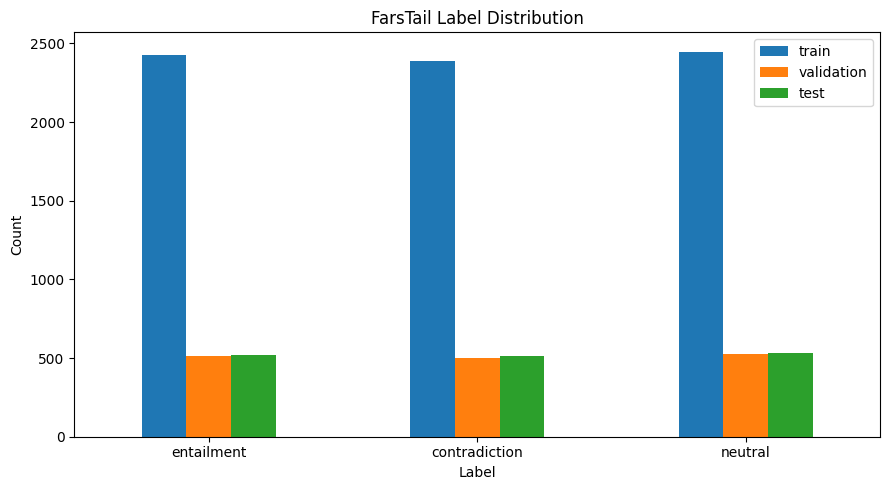

In [6]:
label_distribution = pd.DataFrame({
    "train": train_df["label_id"].value_counts().sort_index(),
    "validation": valid_df["label_id"].value_counts().sort_index(),
    "test": test_df["label_id"].value_counts().sort_index()
})

label_distribution.index = target_names

display(label_distribution)

label_distribution.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("FarsTail Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
class NLIDataset(TorchDataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        encoded = self.tokenizer(
            row["sent1"],
            row["sent2"],
            truncation=True,
            max_length=self.max_length
        )

        # تبدیل BatchEncoding به دیکشنری استاندارد
        item = {key: val for key, val in encoded.items()}
        
        # تبدیل لیبل به تنسور از نوع Long (ضروری برای CrossEntropyLoss)
        item["labels"] = torch.tensor(int(row["label_id"]), dtype=torch.long)

        return item

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "macro_precision": precision,
        "macro_recall": recall
    }


In [9]:
def train_and_evaluate_model(model_name, model_path, output_dir):
    print("=" * 80)
    print(f"Starting model: {model_name}")
    print(f"Model path: {model_path}")
    print("=" * 80)

    set_seed(SEED)

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=3,
        label2id={
            "entailment": 0,
            "contradiction": 1,
            "neutral": 2
        },
        id2label={
            0: "entailment",
            1: "contradiction",
            2: "neutral"
        }
    )

    train_dataset = NLIDataset(
        train_df,
        tokenizer,
        MAX_LENGTH
    )

    valid_dataset = NLIDataset(
        valid_df,
        tokenizer,
        MAX_LENGTH
    )

    test_dataset = NLIDataset(
        test_df,
        tokenizer,
        MAX_LENGTH
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        learning_rate=2e-5,
        warmup_ratio=0.1,            
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=25,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        fp16=False,
        report_to="none",
        seed=SEED,
        data_seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    train_output = trainer.train()

    validation_results = trainer.evaluate(
        eval_dataset=valid_dataset,
        metric_key_prefix="validation"
    )

    prediction_output = trainer.predict(
        test_dataset,
        metric_key_prefix="test"
    )

    y_true = prediction_output.label_ids
    y_pred = np.argmax(prediction_output.predictions, axis=-1)

    test_results = prediction_output.metrics

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=target_names,
        digits=4,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2]
    )

    save_path = os.path.join(output_dir, "final_model")
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    result = {
        "model_name": model_name,
        "model_path": model_path,
        "training_loss": train_output.training_loss,
        "validation_results": validation_results,
        "test_results": test_results,
        "classification_report_dict": report_dict,
        "classification_report_text": report_text,
        "confusion_matrix": cm,
        "y_true": y_true.copy(),
        "y_pred": y_pred.copy(),
        "log_history": list(trainer.state.log_history),
        "saved_model_path": save_path
    }

    print(f"Finished model: {model_name}")
    print(f"Saved to: {save_path}")
    print("Test results:", test_results)
    print(report_text)

    del trainer
    del model
    del tokenizer
    del train_dataset
    del valid_dataset
    del test_dataset
    del data_collator
    del prediction_output

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


In [10]:
models_to_compare = [
    {
        "model_name": "Base FaBERT",
        "model_path": BASE_MODEL_PATH,
        "output_dir": os.path.join(OUTPUT_ROOT, "base_fabert")
    },
    {
        "model_name": "KG-enhanced FaBERT",
        "model_path": KG_MODEL_PATH,
        "output_dir": os.path.join(OUTPUT_ROOT, "kg_fabert")
    }
]


In [11]:
all_results = {}

for model_info in models_to_compare:
    result = train_and_evaluate_model(
        model_name=model_info["model_name"],
        model_path=model_info["model_path"],
        output_dir=model_info["output_dir"]
    )

    all_results[model_info["model_name"]] = result


Starting model: Base FaBERT
Model path: sbunlp/fabert


config.json:   0%|          | 0.00/589 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Finished model: KG-enhanced FaBERT
Saved to: /kaggle/working/farstail_nli_comparison/kg_fabert/final_model
Test results: {'test_loss': 2.1968791484832764, 'test_accuracy': 0.34782608695652173, 'test_macro_f1': 0.2655792201938247, 'test_macro_precision': 0.2341394352438991, 'test_macro_recall': 0.3462781889447116, 'test_runtime': 7.9302, 'test_samples_per_second': 197.221, 'test_steps_per_second': 6.179}
               precision    recall  f1-score   support

   entailment     0.3432    0.7360    0.4681       519
contradiction     0.0000    0.0000    0.0000       510
      neutral     0.3592    0.3028    0.3286       535

     accuracy                         0.3478      1564
    macro avg     0.2341    0.3463    0.2656      1564
 weighted avg     0.2368    0.3478    0.2678      1564



In [12]:
comparison_rows = []

for model_name, result in all_results.items():
    test_results = result["test_results"]
    report = result["classification_report_dict"]

    comparison_rows.append({
        "model": model_name,
        "test_loss": test_results["test_loss"],
        "test_accuracy": test_results["test_accuracy"],
        "test_macro_f1": test_results["test_macro_f1"],
        "test_macro_precision": test_results["test_macro_precision"],
        "test_macro_recall": test_results["test_macro_recall"],
        "entailment_f1": report["entailment"]["f1-score"],
        "contradiction_f1": report["contradiction"]["f1-score"],
        "neutral_f1": report["neutral"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df = comparison_df.sort_values(
    "test_macro_f1",
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

comparison_csv_path = os.path.join(
    OUTPUT_ROOT,
    "fabert_vs_kg_fabert_farstail_comparison.csv"
)

comparison_df.to_csv(
    comparison_csv_path,
    index=False
)

print("Saved comparison to:", comparison_csv_path)


,model,test_loss,test_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,entailment_f1,contradiction_f1,neutral_f1
0,KG-enhanced FaBERT,2.1969,0.3478,0.2656,0.2341,0.3463,0.4681,0.0,0.3286
1,Base FaBERT,2.1968,0.3421,0.1699,0.1140,0.3333,0.0000,0.0,0.5098


Saved comparison to: /kaggle/working/farstail_nli_comparison/fabert_vs_kg_fabert_farstail_comparison.csv


In [13]:
base_row = comparison_df[comparison_df["model"] == "Base FaBERT"].iloc[0]
kg_row = comparison_df[comparison_df["model"] == "KG-enhanced FaBERT"].iloc[0]

improvement = {
    "accuracy_delta": kg_row["test_accuracy"] - base_row["test_accuracy"],
    "macro_f1_delta": kg_row["test_macro_f1"] - base_row["test_macro_f1"],
    "macro_precision_delta": kg_row["test_macro_precision"] - base_row["test_macro_precision"],
    "macro_recall_delta": kg_row["test_macro_recall"] - base_row["test_macro_recall"],
    "entailment_f1_delta": kg_row["entailment_f1"] - base_row["entailment_f1"],
    "contradiction_f1_delta": kg_row["contradiction_f1"] - base_row["contradiction_f1"],
    "neutral_f1_delta": kg_row["neutral_f1"] - base_row["neutral_f1"]
}

improvement_df = pd.DataFrame([improvement])

display(improvement_df.round(4))

improvement_csv_path = os.path.join(
    OUTPUT_ROOT,
    "fabert_vs_kg_fabert_farstail_improvement.csv"
)

improvement_df.to_csv(
    improvement_csv_path,
    index=False
)

print("Saved improvement to:", improvement_csv_path)


,accuracy_delta,macro_f1_delta,macro_precision_delta,macro_recall_delta,entailment_f1_delta,contradiction_f1_delta,neutral_f1_delta
0,0.0058,0.0957,0.1201,0.0129,0.4681,0.0,-0.1812


Saved improvement to: /kaggle/working/farstail_nli_comparison/fabert_vs_kg_fabert_farstail_improvement.csv


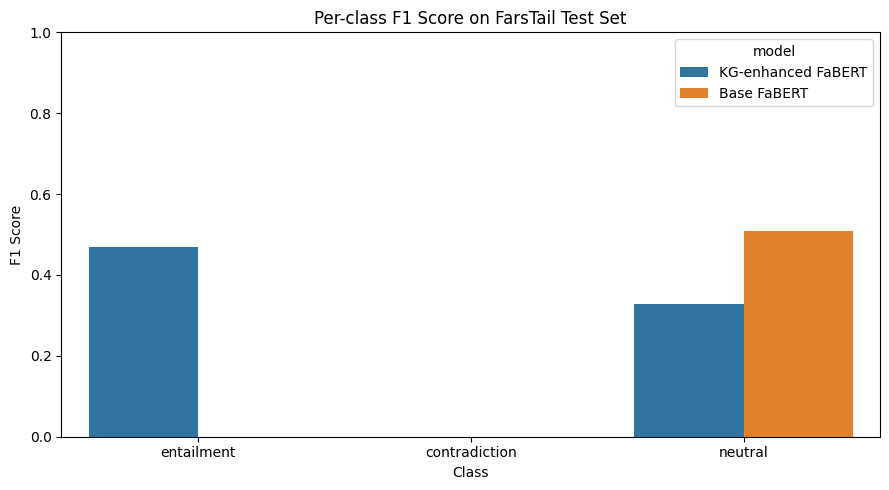

In [14]:
class_f1_df = comparison_df[
    [
        "model",
        "entailment_f1",
        "contradiction_f1",
        "neutral_f1"
    ]
].melt(
    id_vars="model",
    var_name="class",
    value_name="f1"
)

class_f1_df["class"] = class_f1_df["class"].str.replace("_f1", "")

plt.figure(figsize=(9, 5))

sns.barplot(
    data=class_f1_df,
    x="class",
    y="f1",
    hue="model"
)

plt.title("Per-class F1 Score on FarsTail Test Set")
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


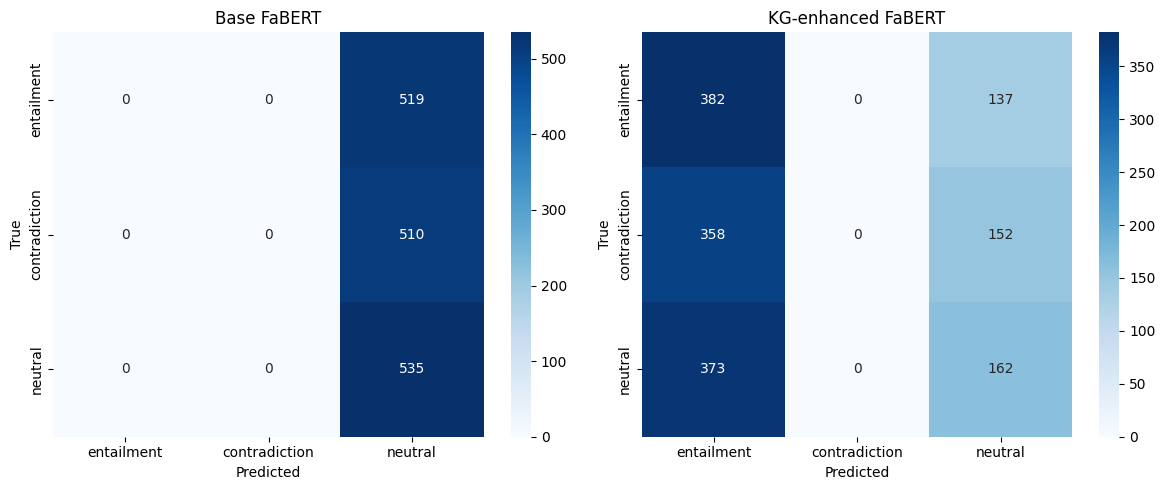

In [15]:
fig, axes = plt.subplots(
    1,
    len(all_results),
    figsize=(6 * len(all_results), 5)
)

if len(all_results) == 1:
    axes = [axes]

for ax, (model_name, result) in zip(axes, all_results.items()):
    cm = result["confusion_matrix"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [16]:
for model_name, result in all_results.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(result["classification_report_text"])


Base FaBERT
               precision    recall  f1-score   support

   entailment     0.0000    0.0000    0.0000       519
contradiction     0.0000    0.0000    0.0000       510
      neutral     0.3421    1.0000    0.5098       535

     accuracy                         0.3421      1564
    macro avg     0.1140    0.3333    0.1699      1564
 weighted avg     0.1170    0.3421    0.1744      1564

KG-enhanced FaBERT
               precision    recall  f1-score   support

   entailment     0.3432    0.7360    0.4681       519
contradiction     0.0000    0.0000    0.0000       510
      neutral     0.3592    0.3028    0.3286       535

     accuracy                         0.3478      1564
    macro avg     0.2341    0.3463    0.2656      1564
 weighted avg     0.2368    0.3478    0.2678      1564

